# Analysis: Mechanistic Variability

We have trained several different Tiny RNN model architectures on a simple reversal task.
What we found is that GRU's trained on the task have varying underlying gating mechanisms.
We sought to minimise this variability by simplifying the architecture, while retaining the performance.


In [250]:
## setup ##
import os
os.chdir('/ceph/behrens/wsilver/reversal/code/')

from NM_TinyRNN.code.measures import analysis
from NM_TinyRNN.code.measures import mechanistic_variability as mech_var
from NM_TinyRNN.code.measures import plotting_stats
from NM_TinyRNN.code.measures import performance as perf

from NM_TinyRNN.code.models import submit_jobs # this is the code used to train models!

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload

CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')

In [259]:
# load datar
reload(submit_jobs)
reload(analysis)
reload(perf)
#construct analysis_df and have a look at a subset of data!
info_df = submit_jobs.get_DA_info_df(folder_name = 'nested_DA_128') #code used to submit jobs
all_models_df = analysis.get_analysis_df(info_df, mode='all') #code to aggregate all paths and some data
performance_df = perf.get_performance_df(all_models_df) #code to recompute evaluations and aggregate with trial-weighted NLL
best_model_df = perf.select_best_outer(performance_df) #

print("Available model types (model_type2):")
print(all_models_df.model_type2.unique())

Model 1_unit_constGate_relu_unipolar_forced has not completed training.
Model 2_unit_constGate_relu_unipolar_forced has not completed training.
Model 1_unit_constGate_relu_unipolar_forced has not completed training.
Model 2_unit_constGate_relu_unipolar_forced has not completed training.
Model 1_unit_constGate_relu_unipolar_forced has not completed training.
Model 2_unit_constGate_relu_unipolar_forced has not completed training.
Model 2_unit_constGate_relu_unipolar_forced has not completed training.
Model 1_unit_constGate_relu_unipolar_forced has not completed training.
Model 1_unit_constGate_relu_unipolar_forced has not completed training.
Model 2_unit_constGate_relu_unipolar_forced has not completed training.
Model 1_unit_constGate_relu_unipolar_forced has not completed training.
Model 2_unit_constGate_relu_unipolar_forced has not completed training.
Model 1_unit_constGate_relu_unipolar_forced has not completed training.
Model 2_unit_constGate_relu_unipolar_forced has not completed tr

## Subject-level examples

To get an idea of what's going on at the level of hidden states across training seeds, let's look at some single-subject examples.

In [261]:
best_model_df.subject_id.unique()

array(['WS01', 'WS02', 'WS05', 'WS08', 'WS09', 'WS10', 'WS13', 'WS14',
       'WS16', 'WS20', 'WS22'], dtype=object)

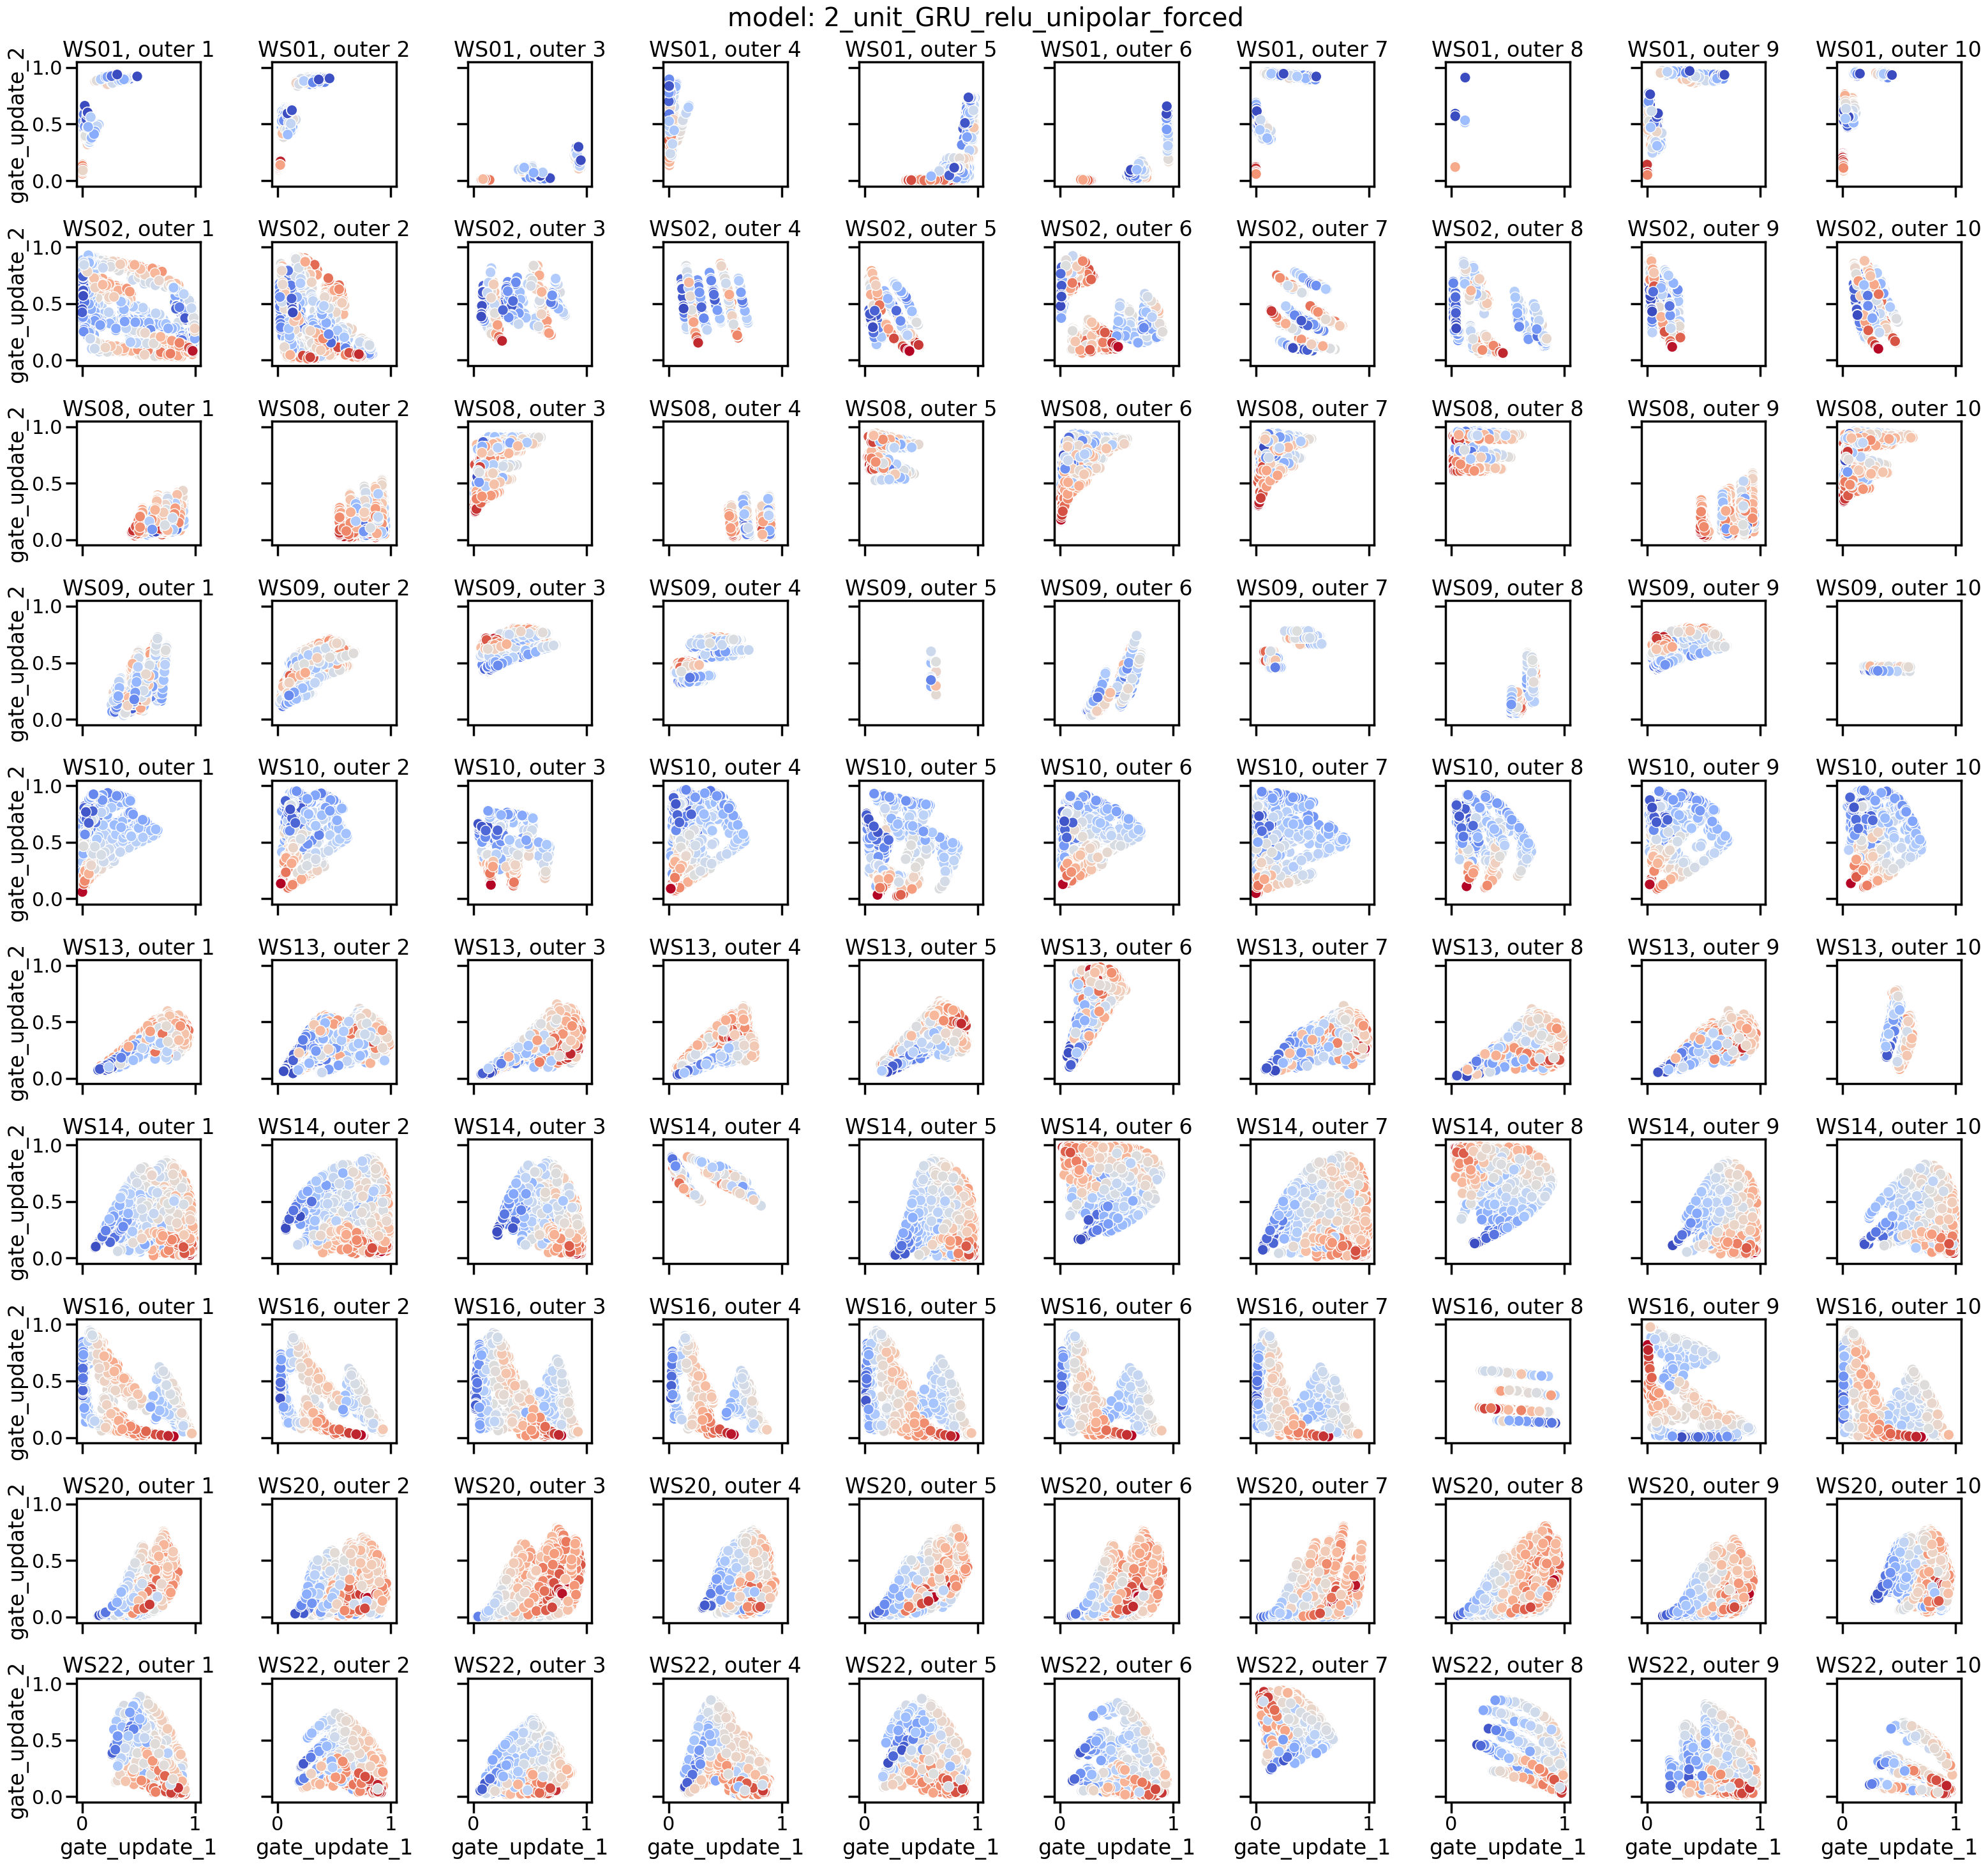

In [162]:
## Have a look at the mechanisms across folds !
subject_list = ['WS01', 'WS02', 'WS08', 'WS09', 'WS10', 
                'WS13', 'WS14', 'WS16','WS20', 'WS22']
sns.set_context('poster')
subset_df = best_model_df.query('model_id=="2_unit_GRU_relu_unipolar_forced"')
subset_df = subset_df[subset_df.subject_id.isin(subject_list)]
subset_df = subset_df.sort_values(by=['subject_id','outer_loop_n'])

fig, ax = plt.subplots(len(subject_list),10,figsize=(32,len(subject_list)*3), sharex=True, sharey=True)
axes = ax.flatten()
for i,each_row in enumerate(subset_df.itertuples()):
    trials_data = analysis.load_data(each_row.trials_data_path)
    sns.scatterplot(trials_data, x= 'gate_update_1',y='gate_update_2',
                    hue = 'logit_value', palette='coolwarm',
                    legend = False, ax = axes[i])
    axes[i].set_title(f'{each_row.subject_id}, outer {each_row.outer_loop_n}')
    axes[i].axis('square')
fig.suptitle(f'model: {each_row.model_id}')
fig.tight_layout()

<Axes: xlabel='logit_past', ylabel='logit_change'>

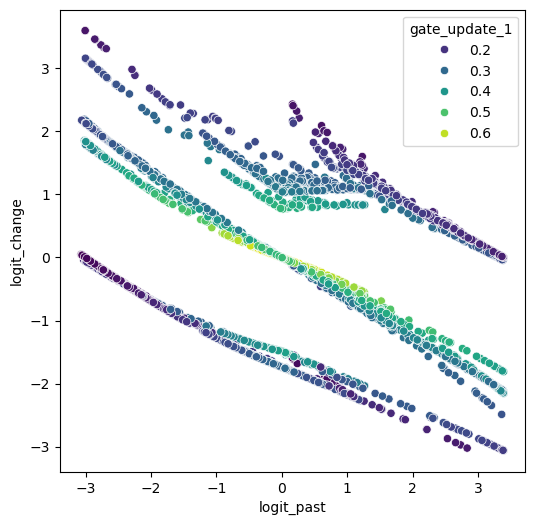

In [21]:
# single subject example
subject_id="WS16"
model_id = "2_unit_monoGRU_relu_unipolar_forced_ndb"
outer_loop_n = 10
select_df = best_model_df.query(f"subject_id=='{subject_id}' and model_id=='{model_id}' and outer_loop_n=={outer_loop_n}")

fig, ax = plt.subplots(1,1,figsize=(6,6))
trials_data = analysis.load_data(select_df.trials_data_path.iloc[0])
sns.scatterplot(trials_data, x= 'logit_past',y='logit_change', hue='gate_update_1',palette='viridis')

In [18]:
(trials_data['logit_value']-trials_data['logit_past']) == trials_data['logit_change']

0       False
1       False
2       False
3       False
4       False
        ...  
4243    False
4244    False
4245    False
4246    False
4247    False
Length: 4248, dtype: bool

In [11]:
trials_data

,hidden_1,hidden_2,gate_update_1,forced_choice,choice,outcome,good_poke,session_folder_name,session_trial_idx,sequence_block_idx,block_trial_idx,trial_type,logit_value,logit_past,logit_change,prob_A,prob_B,split
0,0.395711,0.796407,0.204392,1,0,1,1,WS16/2025-05-01-164959,0,0.0,0.0,"A1,R=1",1.229414,NaN,NaN,0.773716,0.226284,train
1,0.060755,1.022968,0.153534,0,0,1,1,WS16/2025-05-01-164959,1,0.0,1.0,"A1,R=1",2.831740,1.229414,1.602326,0.944367,0.055633,train
2,0.018617,0.377732,0.306427,0,0,0,1,WS16/2025-05-01-164959,2,0.0,2.0,"A1,R=0",1.056307,2.831740,-1.775433,0.741984,0.258016,train
3,0.008282,0.168035,0.444851,0,0,0,1,WS16/2025-05-01-164959,3,0.0,3.0,"A1,R=0",0.469899,1.056307,-0.586408,0.615360,0.384640,train
4,0.503030,0.065036,0.387037,1,1,1,1,WS16/2025-05-01-164959,4,0.0,4.0,"A2,R=1",-1.217089,0.469899,-1.686989,0.228449,0.771551,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4243,0.016780,0.025657,0.511137,0,0,0,1,WS16/2025-05-14-170159,457,123.0,457.0,"A1,R=0",0.028324,0.055413,-0.027089,0.507080,0.492920,eval
4244,0.007935,0.012133,0.472898,0,1,0,1,WS16/2025-05-14-170159,458,123.0,458.0,"A2,R=0",0.013394,0.028324,-0.014929,0.503348,0.496652,eval
4245,0.005139,0.007857,0.647579,1,0,0,1,WS16/2025-05-14-170159,459,123.0,459.0,"A1,R=0",0.008674,0.013394,-0.004720,0.502168,0.497832,eval
4246,0.002709,0.004142,0.527211,0,0,0,1,WS16/2025-05-14-170159,460,123.0,460.0,"A1,R=0",0.004573,0.008674,-0.004101,0.501143,0.498857,eval


## Aligning models

Here we verify code which aligns networks up to permutation and sign flips, where appropriate.



In [62]:
best_model_df

,Index,subject_id,outer_loop_n,model_type,hidden_size,nonlinearity,constraint,decoder_bias,input_encoding,input_forced_choice,...,best_val_CE,weight_seed,sparsity_lambda,energy_lambda,train_CE,val_CE,eval_CE_computed,train_n_free,val_n_free,eval_n_free
2629,300,WS01,1,GRU,1,relu,energy,True,unipolar,True,...,0.526068,3,0.00001,0.001,0.544950,0.527531,0.554518,2302,198,271
2723,310,WS01,2,GRU,1,relu,energy,True,unipolar,True,...,0.517448,9,0.00001,0.001,0.536347,0.518337,0.645731,2202,297,272
2813,320,WS01,3,GRU,1,relu,energy,True,unipolar,True,...,0.520856,9,0.00001,0.001,0.549892,0.521332,0.529968,2276,297,198
2900,330,WS01,4,GRU,1,relu,energy,True,unipolar,True,...,0.524008,8,0.00001,0.001,0.542318,0.525045,0.573330,2276,198,297
2993,340,WS01,5,GRU,1,relu,energy,True,unipolar,True,...,0.520803,4,0.00010,0.001,0.532211,0.521455,0.629359,2078,297,396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4963,559,WS22,6,monoGRU,2,relu,energy,False,unipolar,True,...,0.447902,10,0.00010,0.001,0.452470,0.470092,0.466875,2424,346,322
5053,569,WS22,7,monoGRU,2,relu,energy,False,unipolar,True,...,0.449602,9,0.00010,0.001,0.461325,0.471492,0.395420,2424,346,322
5142,579,WS22,8,monoGRU,2,relu,energy,False,unipolar,True,...,0.414337,5,0.00001,0.001,0.460256,0.486794,0.402914,2449,272,371
5231,589,WS22,9,monoGRU,2,relu,energy,False,unipolar,True,...,0.432326,5,0.00001,0.001,0.452698,0.420188,0.558100,2572,297,223


In [178]:
# Verify that alignment preserves model B's functional output on the same trials_data inputs.
from NM_TinyRNN.code.models import datasets as ds
from NM_TinyRNN.code.measures import mechanistic_variability as mech_var
reload(mech_var)

alignment_rows = (
    best_model_df.query(
        "model_id == '2_unit_GRU_tanh_unipolar_forced' and subject_id == 'WS16'"
    )
    .sort_values('outer_loop_n')
)
assert len(alignment_rows) >= 2, 'Expected at least two WS01 outer-fold models.'

row_a = alignment_rows.iloc[0]
row_b = alignment_rows.iloc[2]
model_a = analysis.load_data(row_a.model_pickle_path)
model_b = analysis.load_data(row_b.model_pickle_path)
model_b_aligned, alignment_info = mech_var.align_rnns(
    model_a, model_b
)
trials_data = analysis.load_data(row_b.trials_data_path)
raw_trials = torch.tensor(
    trials_data[['forced_choice', 'choice', 'outcome']].values,
    dtype=torch.float32,
).unsqueeze(0)
inputs = ds.input_encoder(
    raw_trials, model_b.input_encoding, model_b.input_forced_choice
)

def get_logits_and_choices(model):
    model.eval()
    with torch.no_grad():
        predictions, _ = model(inputs)
        log_probs = predictions.log_softmax(dim=-1)
        logits = (log_probs[..., 0] - log_probs[..., 1]).flatten().cpu().numpy()
        choices = predictions.argmax(dim=-1).flatten().cpu().numpy()
    return logits, choices

def compare_logits(label, left, right):
    delta = left - right
    return {
        'comparison': label,
        'pearson_r': np.corrcoef(left, right)[0, 1],
        'max_abs_diff': np.max(np.abs(delta)),
        'mean_abs_diff': np.mean(np.abs(delta)),
        'allclose_1e-6': np.allclose(left, right, atol=1e-6, rtol=1e-6),
    }

b_before, choices_before = get_logits_and_choices(model_b)
b_after, choices_after = get_logits_and_choices(model_b_aligned)
a_logits, a_choices = get_logits_and_choices(model_a)
saved_logits = trials_data['logit_value'].to_numpy()

print('Selected models:')
print(alignment_rows[['subject_id', 'outer_loop_n', 'model_pickle_path']].head(2).to_string(index=False))
print('\nAlignment metadata:')
print({
    'unaligned_parameter_distance': alignment_info['unaligned_distance'],
    'aligned_parameter_distance': alignment_info['aligned_distance'],
    'perm': alignment_info['perm'].tolist(),
    'transform_vec': alignment_info['transform_vec'].tolist(),
})

print('\nLogit comparisons:')
display(pd.DataFrame([
    compare_logits('saved trials_data vs B before', saved_logits, b_before),
    compare_logits('B before vs B after alignment', b_before, b_after),
    compare_logits('A vs B after alignment', a_logits, b_after),
]))

print('\nChoice comparisons:')
display(pd.DataFrame([{
    'n_trials': len(saved_logits),
    'B before vs B after different choices': np.sum(choices_before != choices_after),
    'A vs B after different choices': np.sum(a_choices != choices_after),
}]))

print('\nFirst 10 logits and choices:')
display(pd.DataFrame({
    'trial': np.arange(min(10, len(saved_logits))),
    'saved_trials_data': saved_logits[:10],
    'B_before': b_before[:10],
    'B_after_aligned': b_after[:10],
    'A': a_logits[:10],
    'B_choice_before': choices_before[:10],
    'B_choice_after': choices_after[:10],
}))

Selected models:
subject_id  outer_loop_n                                                                                                         model_pickle_path
      WS16             1 NM_TinyRNN/data/rnns/nested_DA_8/WS16/GRU/sparsity/outer_fold_1/inner_fold_6/2_unit_GRU_tanh_unipolar_forced_model.pickle
      WS16             2 NM_TinyRNN/data/rnns/nested_DA_8/WS16/GRU/sparsity/outer_fold_2/inner_fold_4/2_unit_GRU_tanh_unipolar_forced_model.pickle

Alignment metadata:
{'unaligned_parameter_distance': 7.916423320770264, 'aligned_parameter_distance': 2.122837543487549, 'perm': [0, 1], 'transform_vec': [1.0, -1.0]}

Logit comparisons:


,comparison,pearson_r,max_abs_diff,mean_abs_diff,allclose_1e-6
0,saved trials_data vs B before,1.000000,7.481598e-07,5.780014e-08,True
1,B before vs B after alignment,1.000000,0.000000e+00,0.000000e+00,True
2,A vs B after alignment,0.973004,1.297560e+00,3.300463e-01,False



Choice comparisons:


,n_trials,B before vs B after different choices,A vs B after different choices
0,4248,0,270



First 10 logits and choices:


,trial,saved_trials_data,B_before,B_after_aligned,A,B_choice_before,B_choice_after
0,0,0.953325,0.953325,0.953325,1.500748,0,0
1,1,2.254701,2.254701,2.254701,2.311448,0,0
2,2,0.524815,0.524815,0.524815,0.615753,0,0
3,3,0.118310,0.118310,0.118310,-0.014013,0,0
4,4,-1.198518,-1.198518,-1.198518,-1.605858,1,1
5,5,-2.069475,-2.069475,-2.069475,-2.076670,1,1
6,6,-2.415872,-2.415872,-2.415872,-2.289600,1,1
7,7,-2.521825,-2.521825,-2.521825,-2.409630,1,1
8,8,-0.890375,-0.890375,-0.890375,-0.091050,1,1
9,9,-2.700292,-2.700292,-2.700292,-1.854356,1,1


/tmp/ipykernel_4071905/12629713.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


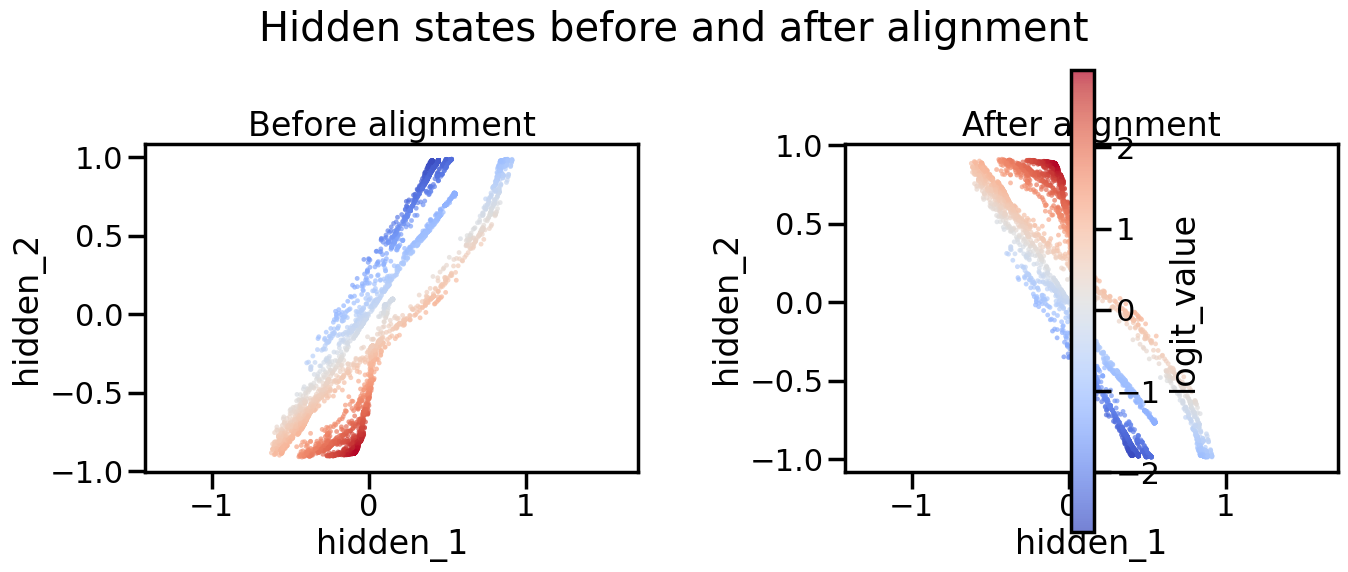

In [157]:
# Plot hidden states before and after alignment using the same logit hue.
with torch.no_grad():
    _, hidden_before = model_b(inputs)
    _, hidden_after = model_b_aligned(inputs)

hidden_before = hidden_before[0].cpu().numpy()
hidden_after = hidden_after[0].cpu().numpy()

hidden_plot_data = [
    pd.DataFrame({
        'hidden_1': hidden_before[:, 0],
        'hidden_2': hidden_before[:, 1],
        'logit_value': b_before,
    }).assign(alignment='Before alignment'),
    pd.DataFrame({
        'hidden_1': hidden_after[:, 0],
        'hidden_2': hidden_after[:, 1],
        'logit_value': b_before,
    }).assign(alignment='After alignment'),
]
hidden_plot_data = pd.concat(hidden_plot_data, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)
for alignment, ax in zip(['Before alignment', 'After alignment'], axes):
    plot_data = hidden_plot_data[hidden_plot_data['alignment'] == alignment]
    scatter = ax.scatter(
        plot_data['hidden_1'],
        plot_data['hidden_2'],
        c=plot_data['logit_value'],
        cmap='coolwarm',
        s=12,
        alpha=0.7,
        linewidths=0,
    )
    ax.set_title(alignment)
    ax.set_xlabel('hidden_1')
    ax.set_ylabel('hidden_2')
    ax.set_aspect('equal', adjustable='datalim')

fig.colorbar(scatter, ax=axes, label='logit_value')
fig.suptitle('Hidden states before and after alignment')
fig.tight_layout()
plt.show()

## Similarities in activations

For each subject, we select the 10 best models, then run each model on data from all subjects. 
We then compute the pearson correlation between logits, hidden states, and update gate activations. 

We show that both within subjects (across folds) and across subjects, a standard GRU will have similar logits but large variability in hidden states and gate activations. We reduced this variance by simplifying the gated architecture, adding biological constraints, and removing decoder bias terms.



In [282]:
best_model_df.model_type2.unique()

array(['GRU+BC', 'GRU+BC-DB', 'GRU', 'lightGRU+BC', 'monoGRU_abs',
       'monoGRU+BC', 'monoGRU+BC-DB', 'vanilla+BC', 'vanilla+BC-DB',
       'vanilla', 'monoGRU_hidden_only+BC-DB', 'monoGRU_no_hidden+BC-DB'],
      dtype=object)

In [283]:
# Across all gating architectures - gating variability.
## Figure 2: variability in GRU model mechanisms.
reload(mech_var)
model_list = ['GRU', 'GRU+BC', 'GRU+BC-DB', 
              'lightGRU+BC',
              'monoGRU+BC', 'monoGRU+BC-DB', 
              'vanilla', 'vanilla+BC', 'vanilla+BC-DB']

subject_list = best_model_df.subject_id.unique()
USE_BEST_MODELS = True

source_df = best_model_df if USE_BEST_MODELS else all_models_df
select_models = source_df.query('hidden_size==2 and input_encoding == "unipolar"').copy()
#select_models = select_models.query('subject_id=="WS16"')
select_models = select_models[select_models.model_type2.isin(model_list)]
select_models = select_models[select_models.subject_id.isin(subject_list)]
select_models['model_id'] = select_models.model_type2
#print(select_models)
sim_df = mech_var.compute_similarities(select_models, similarity_measure='pearson', use_cache = False)

sim_df

KeyboardInterrupt: 

0.7381186192402929

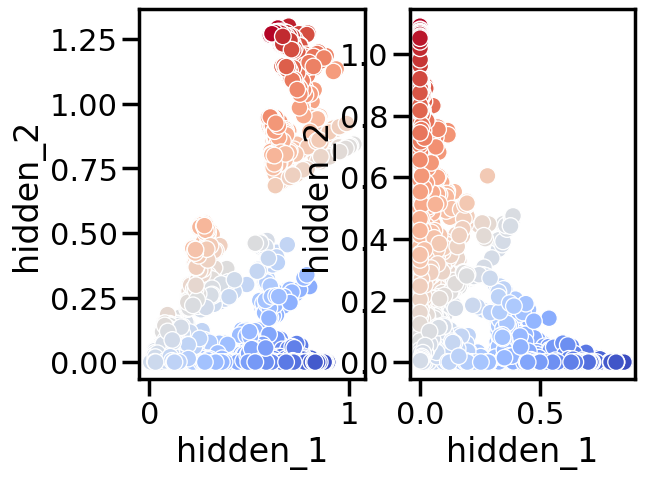

In [234]:
example = sim_df.query('subject_A=="WS16" and model_id=="monoGRU+BC-DB" and gate_update_similarity<0.0')
pair = example.iloc[0]
model_id = "2_unit_monoGRU_relu_unipolar_forced_ndb"
model_a_df = best_model_df.query('model_id==@model_id and subject_id=="WS16" and outer_loop_n == @pair.model_A_outer_n').iloc[0]
model_b_df = best_model_df.query('model_id==@model_id and subject_id=="WS16" and outer_loop_n == @pair.model_B_outer_n').iloc[0]

#align models
model_a = analysis.load_data(model_a_df.model_pickle_path)
model_b = analysis.load_data(model_b_df.model_pickle_path)
model_b_aligned, alignment_info = mech_var.align_rnns(model_a, model_b)

#run model b on model a data
trials_a = analysis.load_data(model_a_df.trials_data_path)

raw = torch.tensor(
    trials_a[["forced_choice", "choice", "outcome"]].to_numpy(),
    dtype=torch.float32,
).unsqueeze(0)
inputs = ds.input_encoder(raw, model_a.input_encoding, model_a.input_forced_choice)
model_device = next(model_a.parameters()).device
inputs = inputs.to(model_device)

trials_b = mech_var._run_model_on_trials(model_b_aligned, trials_a, inputs)


fig, ax = plt.subplots(1,2)

sns.scatterplot(trials_a, x='hidden_1',y='hidden_2', hue='logit_value', 
                palette='coolwarm', legend=False, ax=ax[0])

sns.scatterplot(trials_b, x='hidden_1',y='hidden_2', hue='logit_value', 
                palette='coolwarm', legend=False, ax=ax[1])


mech_var.compute_activation_similarity(model_a, model_b_aligned, inputs)

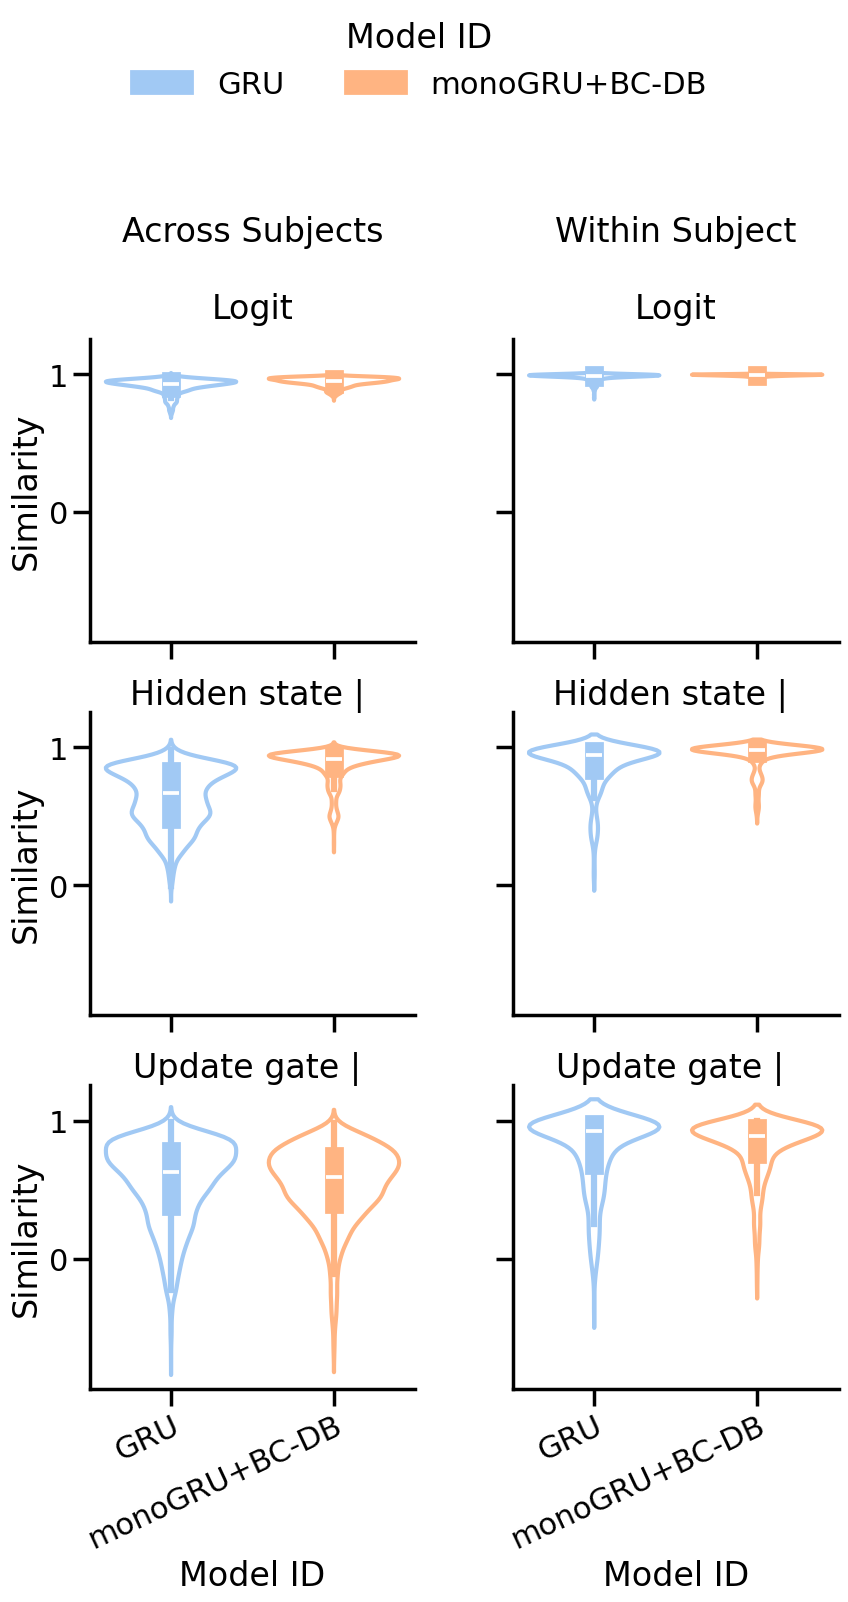

In [182]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

model_list = ['GRU', 'monoGRU+BC-DB']
component_map = {
    'logit_value_similarity': 'Logit',
    'hidden_similarity': 'Hidden state',
    'gate_update_similarity': 'Update gate',
}
similarity_columns = list(component_map)

# Reshape the current wide similarity dataframe for the facet plot.
plot_df = (
    sim_df.loc[
        sim_df['model_id'].isin(model_list),
        ['model_id', 'within_subject', *similarity_columns],
    ]
    .melt(
        id_vars=['model_id', 'within_subject'],
        value_vars=similarity_columns,
        var_name='component',
        value_name='similarity',
    )
    .dropna(subset=['similarity'])
)
plot_df['component_clean'] = plot_df['component'].map(component_map)

sns.set_context('poster')
palette = dict(zip(model_list, sns.color_palette('pastel', n_colors=len(model_list))))

# Disable Seaborn's automatic legend for compatibility with this violin plot.
g = sns.catplot(
    data=plot_df,
    row='component_clean',
    col='within_subject',
    y='similarity',
    x='model_id',
    hue='model_id',
    hue_order=model_list,
    palette=palette,
    row_order=['Logit', 'Hidden state', 'Update gate'],
    col_order=[False, True],
    kind='violin',
    fill=False,
    aspect=1.0,
    legend=False,
)

g.set_titles(col_template='', row_template='{row_name}')
g.axes[0, 0].set_title('Across Subjects\n\nLogit', pad=15)
g.axes[0, 1].set_title('Within Subject\n\nLogit', pad=15)
g.set_axis_labels(x_var='Model ID', y_var='Similarity')

for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=25, ha='right', rotation_mode='anchor')

legend_handles = [
    mpatches.Patch(color=palette[model_id], label=model_id)
    for model_id in model_list
]
g.figure.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(legend_handles),
    title='Model ID',
    frameon=False,
)

plt.subplots_adjust(top=0.85, bottom=0.15)
plt.show()

In [232]:
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

model_list = ['GRU', 'monoGRU+BC-DB']
component_map = {
    'logit_value_similarity': 'Logit',
    'hidden_similarity': 'Hidden state',
    'gate_update_similarity': 'Update gate',
}
similarity_columns = list(component_map.keys())

# Ensure we have the necessary columns
# sim_df must contain: model_id, within_subject, subject_id (for within), subject_A (for across), and similarity columns

results = []

# Loop through each component and each condition (within vs across)
for component in similarity_columns:
    comp_name = component_map[component]
    
    for within_status in [True, False]:
        cond_label = 'Within-Subject' if within_status else 'Across-Subject'
        pairing_col = 'subject_A' if within_status else 'subject_A'
        
        # Filter subset
        df_sub = sim_df[
            sim_df['model_id'].isin(model_list) & 
            (sim_df['within_subject'] == within_status)
        ][['model_id', pairing_col, component]].dropna()
        
        # Pivot to pair properly
        pivot_df = df_sub.pivot_table(
            index=pairing_col,
            columns='model_id',
            values=component
        ).dropna()
        
        if len(pivot_df) < 2:
            continue
            
        m1, m2 = model_list[0], model_list[1]
        val1 = pivot_df[m1]
        val2 = pivot_df[m2]
        
        # Paired t-test
        t_stat, p_val_t = stats.ttest_rel(val1, val2)
        
        # Wilcoxon signed-rank test
        try:
            w_stat, p_val_w = stats.wilcoxon(val1, val2)
        except ValueError:
            w_stat, p_val_w = float('nan'), float('nan')
            
        results.append({
            'Component': comp_name,
            'Condition': cond_label,
            'N_pairs': len(pivot_df),
            't_stat': t_stat,
            'p_val_t': p_val_t,
            'wilcoxon_stat': w_stat,
            'p_val_wilcoxon': p_val_w
        })

stats_df = pd.DataFrame(results)

# Apply Benjamini-Hochberg (FDR) correction across all tests
# We can correct the t-test p-values (and/or Wilcoxon p-values separately)
if not stats_df.empty:
    _, p_val_t_corr, _, _ = multipletests(stats_df['p_val_t'], method='fdr_bh')
    _, p_val_w_corr, _, _ = multipletests(stats_df['p_val_wilcoxon'], method='fdr_bh')
    
    stats_df['p_val_t_corrected'] = p_val_t_corr
    stats_df['p_val_wilcoxon_corrected'] = p_val_w_corr

# Display the formatted table
print(stats_df[['Component', 'Condition', 'N_pairs', 't_stat', 'p_val_t', 'p_val_t_corrected']])

      Component       Condition  N_pairs     t_stat   p_val_t  \
0         Logit  Within-Subject       11  -2.191339  0.053215   
1         Logit  Across-Subject       10  -2.671148  0.025574   
2  Hidden state  Within-Subject       11  -2.900276  0.015826   
3  Hidden state  Across-Subject       10 -10.307307  0.000003   
4   Update gate  Within-Subject       11  -0.634299  0.540124   
5   Update gate  Across-Subject       10   0.253301  0.805727   

   p_val_t_corrected  
0           0.079823  
1           0.051149  
2           0.047478  
3           0.000017  
4           0.648149  
5           0.805727  


<>:58: SyntaxWarning: invalid escape sequence '\D'
<>:58: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_4071905/2461317274.py:58: SyntaxWarning: invalid escape sequence '\D'
  axes[0, column].set(xlabel = 'logit, $L_t$', ylabel = 'Logit change, $\Delta L_t$')


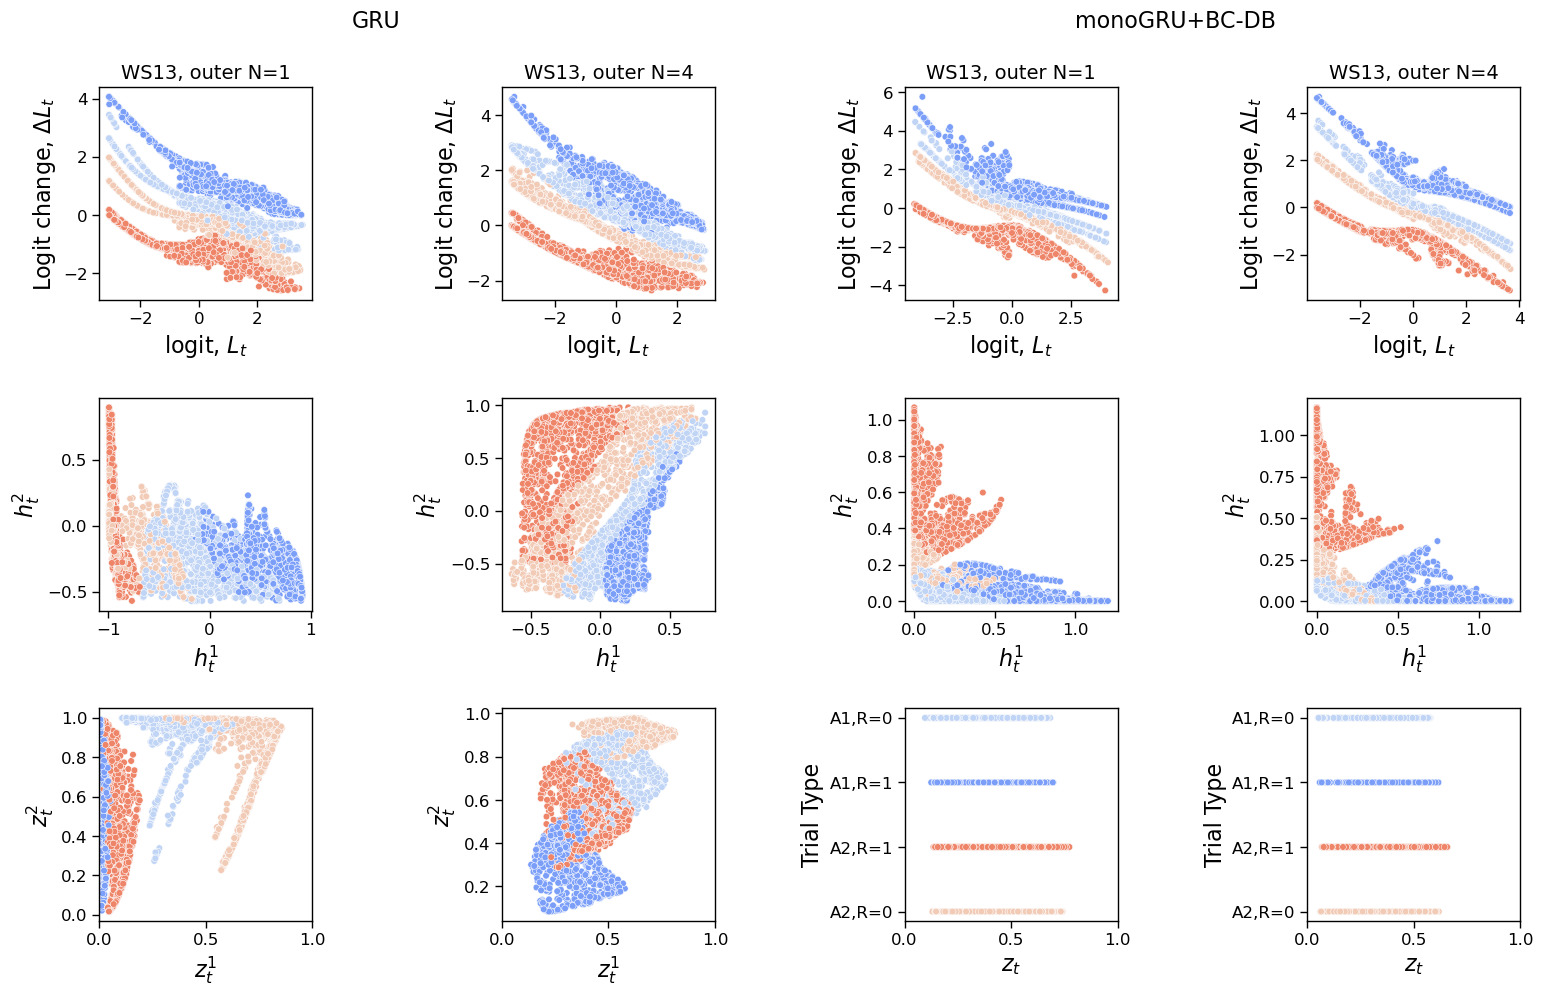

In [205]:
# Compare best models from matched outer folds across the two architectures
subject_id = "WS13"

# Use a low-similarity within-subject GRU pair as the example.
gru_sim_df = sim_df.query(
    'model_id=="GRU" and 0.0 < hidden_similarity < 0.5 and within_subject==True' 
)
subject_specific = gru_sim_df.query(
    f'subject_A=="{subject_id}" and subject_B=="{subject_id}" and '
    f'trial_subject=="{subject_id}"'
)
example = subject_specific.iloc[0]
outer_folds = [example.model_A_outer_n, example.model_B_outer_n]

# Select each architecture's best inner-fold model for the same outer folds.
selected_models = best_model_df.query(
    f'subject_id=="{subject_id}" and hidden_size==2 and '
    'input_encoding=="unipolar" and '
    'model_type2 in ["GRU", "monoGRU+BC-DB"]'
).copy()
selected_models = selected_models[
    selected_models.outer_loop_n.isin(outer_folds)
].sort_values(["model_type2", "outer_loop_n"])

# Keep the GRU pair first, followed by the matched monoGRU pair.
plot_models = []
for model_type in ["GRU", "monoGRU+BC-DB"]:
    model_rows = selected_models[
        selected_models.model_type2 == model_type
    ].sort_values("outer_loop_n")
    plot_models.extend(model_rows.itertuples())

assert len(plot_models) == 4, (
    "Expected two best outer-fold models for each architecture."
)

sns.set_context("paper")
cp = sns.color_palette("coolwarm", n_colors=4)
color_map = {
    "A1,R=0": cp[1], "A1,R=1": cp[0],
    "A2,R=0": cp[2], "A2,R=1": cp[3],
}

fig, axes = plt.subplots(3, 4, figsize=(16, 10), squeeze=False)
for column, each_model in enumerate(plot_models):
    trials_data = analysis.load_data(each_model.trials_data_path)
    column_title = (
        f"{each_model.subject_id}, "
        f"outer N={each_model.outer_loop_n}"
    )

    sns.scatterplot(
        data=trials_data,
        x="logit_past", y="logit_change",
        hue="trial_type", palette=color_map,
        legend=False, ax=axes[0, column],
    )
    axes[0, column].set(xlabel = 'logit, $L_t$', ylabel = 'Logit change, $\Delta L_t$')

    sns.scatterplot(
        data=trials_data,
        x="hidden_1", y="hidden_2",
        hue="trial_type", palette=color_map,
        legend=False, ax=axes[1, column],
    )
    axes[1,column].set(xlabel = '$h^1_t$', ylabel = '$h^2_t$')

   
    if 'gate_update_2' in trials_data.columns:
        gate_y = 'gate_update_2'
        axes[2,column].set(xlabel = '$z^1_t$', ylabel = '$z^2_t$')
    else:
        gate_y = 'trial_type'
        axes[2,column].set(xlabel = '$z_t$', ylabel = 'Trial Type')
          
    sns.scatterplot(
        data=trials_data,
        x="gate_update_1", y=gate_y,
        hue="trial_type", palette=color_map,
        legend=False, ax=axes[2, column],
    )
    
    for row in range(3):
        axes[row, column].set_box_aspect(1)
        axes[row, column].tick_params(labelsize=12)
        axes[row, column].xaxis.label.set_size(16)
        axes[row, column].yaxis.label.set_size(16)

    axes[0, column].set_title(column_title, fontsize=14)
    axes[2, column].set_xlim(0, 1)
    axes[2, column].set_xticks([0, 0.5, 1])

fig.text(0.25, 0.99, "GRU", ha="center", va="top", fontsize=16)
fig.text(0.75, 0.99, "monoGRU+BC-DB", ha="center", va="top", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.95), w_pad=2.5, h_pad=2.5)
plt.show()

## Similarities in weights

/nfs/nhome/live/cburns/miniconda3/envs/NM_TinyRNN/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


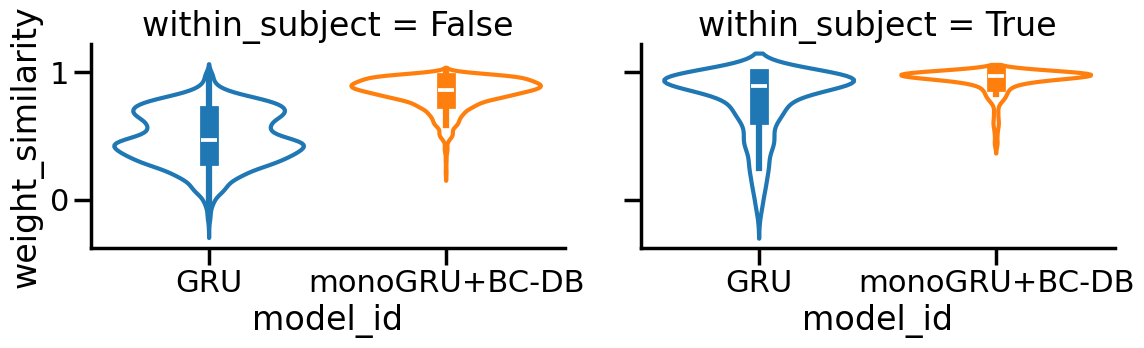

In [224]:
sns.set_context('poster')
g = sns.FacetGrid(data=sim_df.query('model_id in ["GRU", "monoGRU+BC-DB"]'),
                 hue='model_id', col='within_subject', height=4, aspect=1.5, sharey=True)

g.map(sns.violinplot, 'model_id','weight_similarity', fill=False)

In [227]:
import pandas as pd
from scipy import stats

# 1. Filter the dataset for the two models of interest
df_subset = sim_df[sim_df['model_id'].isin(['GRU', 'monoGRU+BC-DB'])].copy()

# ==========================================
# 2. WITHIN-SUBJECT STATISTICS
# ==========================================
print('--- Within-Subject Analysis ---')
# Adjust the condition below if 'within_subject' is stored differently (e.g., string 'True')
df_within = df_subset[df_subset['within_subject'] == True]

# Pivot so each row represents a unique subject_id, with columns for each model
pivot_within = df_within.pivot_table(
    index='subject_A', 
    columns='model_id', 
    values='weight_similarity'
).dropna()

# Run Paired t-test
t_stat_w, p_val_w = stats.ttest_rel(pivot_within['GRU'], pivot_within['monoGRU+BC-DB'])
print(f'Paired t-test: t = {t_stat_w:.3f}, p = {p_val_w:.4f}')

# Run Wilcoxon signed-rank test (non-parametric alternative)
w_stat_w, w_p_val_w = stats.wilcoxon(pivot_within['GRU'], pivot_within['monoGRU+BC-DB'])
print(f'Wilcoxon test: W = {w_stat_w}, p = {w_p_val_w:.4f}')


# ==========================================
# 3. ACROSS-SUBJECT STATISTICS (Paired by subject_A)
# ==========================================
print('\n--- Across-Subject Analysis (Paired by subject_A) ---')
df_across = df_subset[df_subset['within_subject'] == False]

# Pivot so each row represents a unique subject_A, with columns for each model
pivot_across = df_across.pivot_table(
    index='subject_A', 
    columns='model_id', 
    values='weight_similarity'
).dropna()

# Run Paired t-test
t_stat_a, p_val_a = stats.ttest_rel(pivot_across['GRU'], pivot_across['monoGRU+BC-DB'])
print(f'Paired t-test: t = {t_stat_a:.3f}, p = {p_val_a:.4f}')

# Run Wilcoxon signed-rank test
w_stat_a, w_p_val_a = stats.wilcoxon(pivot_across['GRU'], pivot_across['monoGRU+BC-DB'])
print(f'Wilcoxon test: W = {w_stat_a}, p = {w_p_val_a:.4f}')

--- Within-Subject Analysis ---
Paired t-test: t = -3.792, p = 0.0035
Wilcoxon test: W = 0.0, p = 0.0010

--- Across-Subject Analysis (Paired by subject_A) ---
Paired t-test: t = -13.400, p = 0.0000
Wilcoxon test: W = 0.0, p = 0.0020


In [ ]:
example_models = best_model_df.query('model_id=="2_unit_monoGRU_relu_unipolar_forced_ndb" and subject_id=="WS18"')
for each_model in example_models.itertuples():
    trials_data= analysis.load_data(each_model.trials_data_path)
    model = analysis.load_data(each_model.model_pickle_path)
    break

trials_data
for name, p in model.named_parameters():
    print(name,p)

rnn.W_ih Parameter containing:
tensor([[-0.3913, -0.2319],
        [-1.1652,  0.7334],
        [ 1.0996,  0.9367]], requires_grad=True)
rnn.W_hh Parameter containing:
tensor([[ 0.3558, -0.1875],
        [-0.2154,  0.0904]], requires_grad=True)
rnn.W_iz Parameter containing:
tensor([[ 0.7260],
        [ 0.2169],
        [-1.1508]], requires_grad=True)
rnn.W_hz Parameter containing:
tensor([[-0.4848],
        [-1.3845]], requires_grad=True)
rnn.bias_h Parameter containing:
tensor([ 0.1719, -0.6601], requires_grad=True)
rnn.bias_z Parameter containing:
tensor(-0.1911, requires_grad=True)
rnn.hidden_0 Parameter containing:
tensor([ 0.5322, -0.0322], requires_grad=True)
rnn.z_0 Parameter containing:
tensor([0.0017], requires_grad=True)
decoder.weight Parameter containing:
tensor([[ 1.2201, -1.1064],
        [-1.2013,  1.1067]], requires_grad=True)


## Supplementary


/nfs/nhome/live/cburns/miniconda3/envs/NM_TinyRNN/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


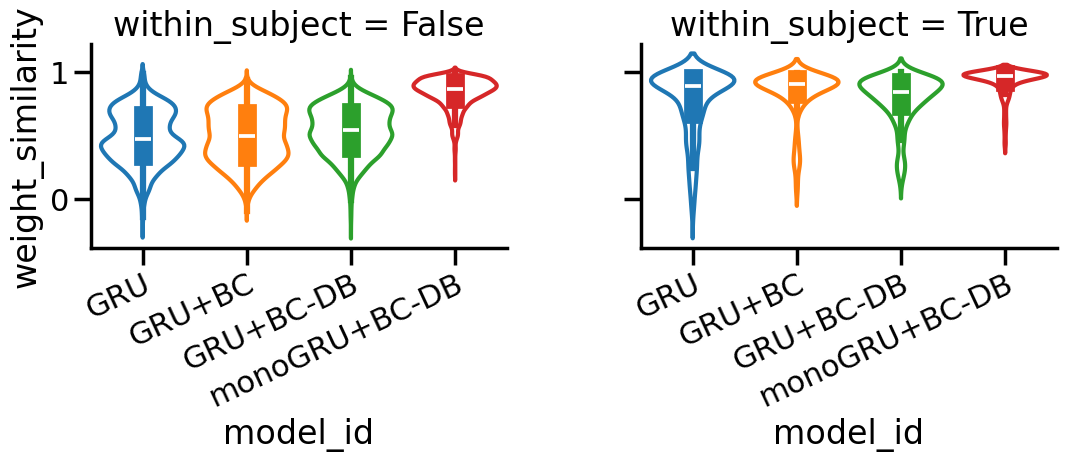

In [267]:
# looking at weight similarity across a bunch of GRU models with constraints
sns.set_context('poster')
g = sns.FacetGrid(data=sim_df,
                 hue='model_id', col='within_subject', height=4, aspect=1.5, sharey=True)

g.map(sns.violinplot, 'model_id','weight_similarity', fill=False)
# Loop through all axes in the FacetGrid to rotate the x-tick labels
for ax in g.axes.flat:
    plt.setp(
        ax.get_xticklabels(), rotation=25, ha='right', rotation_mode='anchor'
    )

/tmp/ipykernel_2544384/1390778657.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['context->update gate', 'action->update gate', 'outcome->update gate','hidden->update gate'])


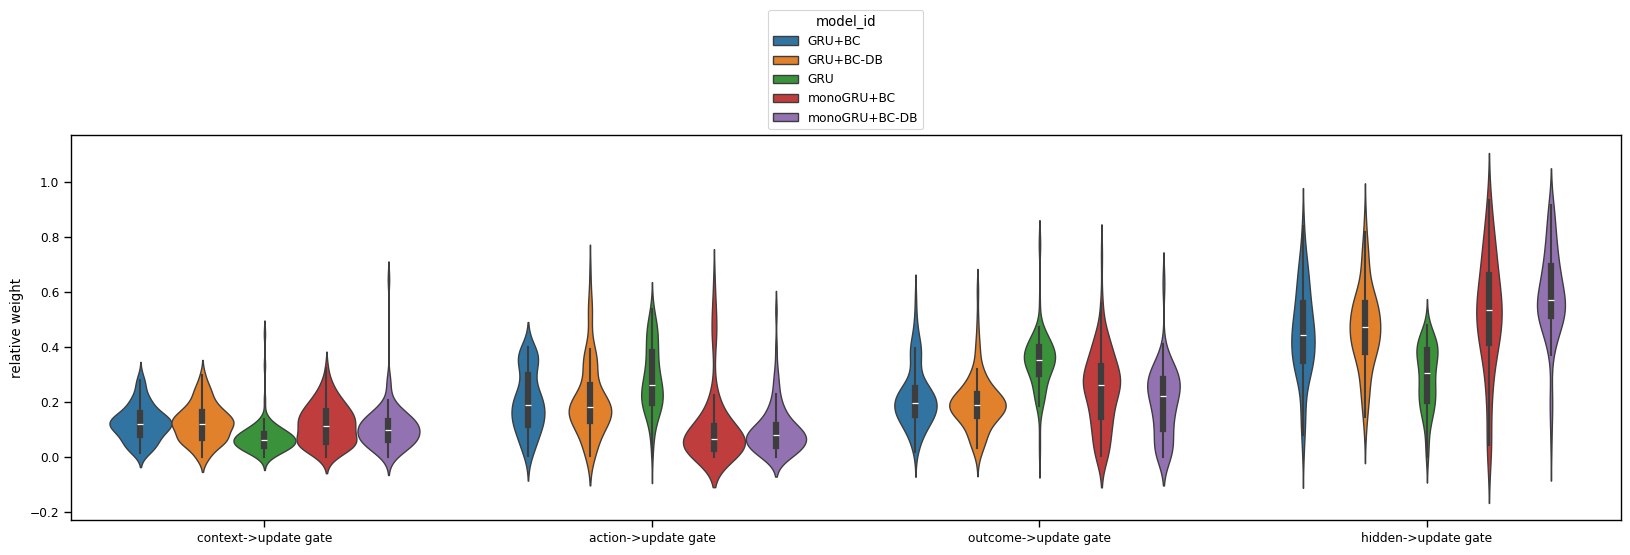

In [37]:
reload(mech_var)
contributions_df = mech_var.parameter_contribution_df(select_models)
update_gate_df = contributions_df[contributions_df.variable.str.contains('update')]
update_gate_df = update_gate_df.dropna()

fig, ax = plt.subplots(figsize=(20, 5))
palette = sns.color_palette('pastel', n_colors=16)  # or 'husl', 'pastel', etc.

sns.violinplot(data=update_gate_df, 
               x='variable', y='value', 
               hue='model_id', 
              dodge=True, ax=ax, )
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, 1))
ax.set_xticklabels(['context->update gate', 'action->update gate', 'outcome->update gate','hidden->update gate'])
handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles, ['GRU', 'monoGRU*'], title='', loc='lower center', 
#         bbox_to_anchor=(0.5, 1))
ax.set(xlabel = '',ylabel='relative weight')
plt.show()


In [35]:
params_dict = {k:v.detach().numpy() for k,v in model.named_parameters()}
np.abs(params_dict['rnn.W_hh'])

array([[0.35579574, 0.18745962],
       [0.21537717, 0.09037313]], dtype=float32)